<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>ML</b></center>
<center><b><h1>Name : siya Kansagara</b></center>
<center><b><h1>Enrollement no: 25010101642</b></center>
<center><b><h1>Lab - 15</b></center>    
<pre>    

# Digit Recognition with TensorFlow

**Objective:** Build a neural network to recognize handwritten digits using the famous MNIST dataset.

In the previous lab, we built a single neuron from scratch. Now, it's time to step up and use TensorFlow to build a full neural network.

### Step 1: Getting the Tools Ready
First, we need to import TensorFlow and some other useful libraries.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### Step 2: Load the MNIST Dataset
MNIST is like the "Hello World" of machine learning. It contains 70,000 grayscale images of hand-drawn digits (0 through 9). Keras has it built-in, so downloading it is super easy.

In [2]:
mnist = tf.keras.datasets.mnist

# Split into training and testing sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Step 3: Peek at the Data
It's always a good idea to actually look at the data before feeding it into a model. Let's see what the first image looks like.

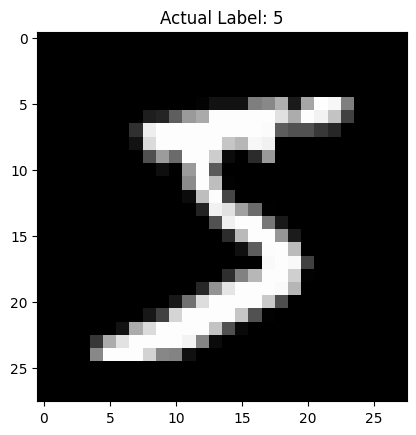

In [3]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Actual Label: {y_train[0]}")
plt.show()

### Step 4: Preprocessing (Scaling)
The pixel values range from 0 to 255. Neural networks work much better when input values are small, usually between 0 and 1. So, we'll just divide everything by 255.

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Data scaled successfully.")

Data scaled successfully.


### Step 5: Build the Neural Network
We are going to build a simple feed-forward network.
- **Flatten layer:** Converts the 28x28 2D image into a 1D array of 784 pixels.
- **Dense layer (Hidden):** 128 neurons with ReLU activation.
- **Dense layer (Output):** 10 neurons (one for each digit 0-9) with Softmax activation to get probabilities.

In [5]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Step 6: Compile the Model
Before training, we need to specify a few more things:
- **Optimizer:** How the model updates its weights (Adam is a solid default).
- **Loss function:** How we measure mistakes during training.
- **Metrics:** We want to track accuracy.

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Step 7: Train the Network!
Now we pass the training data to the model. We'll run it for 5 epochs (going through the whole dataset 5 times).

In [7]:
print("Starting training...")
model.fit(x_train, y_train, epochs=5)

Starting training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9271 - loss: 0.2558
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9679 - loss: 0.1109
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9769 - loss: 0.0770
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9827 - loss: 0.0570
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9872 - loss: 0.0435


### Step 8: Test it out
Training accuracy is great, but what really matters is how it performs on data it hasn't seen before (the test set).

In [8]:
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

313/313 - 1s - 2ms/step - accuracy: 0.9763 - loss: 0.0795

Test Accuracy: 97.63%
